In [1]:
import dotenv
%load_ext dotenv
%dotenv

import os
import platform
import json
import random
import time

import jax
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from absl import app, flags
from ml_collections import config_flags

from agents import agents
from envs.env_utils import make_env_and_datasets
from utils.datasets import Dataset, ReplayBuffer
from utils.evaluation import evaluate, flatten, supply_rng
from utils.flax_utils import restore_agent

import jax
import numpy as np
import matplotlib.pyplot as plt

def supply_rng(f, rng=jax.random.PRNGKey(0)):
    """Helper function to split the random number generator key before each call to the function."""

    def wrapped(*args, **kwargs):
        nonlocal rng
        rng, key = jax.random.split(rng)
        return f(*args, seed=key, **kwargs)

    return wrapped

# Configuration
env_name = "antmaze-large-navigate-singletask-task2-v0"
seed = 0
buffer_size = 2000000
eval_episodes = 10

# Agent paths and epochs
fbrac_antmaze_task1="/mnt/nas/jaehyeok/fql/exp/fql/Debug/fbrac_antmaze-large-navigate-singletask-task1-v0_sd002_20250908_200922_utd-ratio1"
fbrac_antmaze_task2="/mnt/nas/jaehyeok/fql/exp/fql/Debug/fbrac_antmaze-large-navigate-singletask-task2-v0_sd000_20250919_172341_utd-ratio1"
fbrac_antmaze_task3="/mnt/nas/jaehyeok/fql/exp/fql/Debug/fbrac_antmaze-large-navigate-singletask-task3-v0_sd000_20250919_172433_utd-ratio1"

# agent_path=a5_jacb_reg_e5_agent_path
agent_path=fbrac_antmaze_task2
restore_epoch=1000000

# Make environment and datasets
env, eval_env, train_dataset, val_dataset = make_env_and_datasets(env_name, frame_stack=None)
train_dataset = Dataset.create(**train_dataset)
train_dataset = ReplayBuffer.create_from_initial_dataset(
    dict(train_dataset), size=max(buffer_size, train_dataset.size + 1)
)

# Initialize random seeds
random.seed(seed)
np.random.seed(seed)
example_batch = train_dataset.sample(1)

# Load FQL agent configuration and create agent
from agents.fbrac import get_config as get_fbrac_config
fbrac_config = get_fbrac_config()

fbrac_agent_class = agents[fbrac_config['agent_name']]
fbrac_agent = fbrac_agent_class.create(
    seed,
    example_batch['observations'],
    example_batch['actions'],
    fbrac_config,
)

# Restore trained models
if agent_path and restore_epoch:
    fbrac_agent = restore_agent(fbrac_agent, agent_path, restore_epoch)
    print(f"FBRAC agent restored from {agent_path} at epoch {restore_epoch}")

print("Models loaded successfully!")

key = jax.random.PRNGKey(seed)
key

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/home/jaehyeok/miniconda3/envs/fql/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:14: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
/home/jaehyeok/miniconda3/envs/fql/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:14: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead


Restored from /mnt/nas/jaehyeok/fql/exp/fql/Debug/fbrac_antmaze-large-navigate-singletask-task2-v0_sd000_20250919_172341_utd-ratio1/params_1000000.pkl
FBRAC agent restored from /mnt/nas/jaehyeok/fql/exp/fql/Debug/fbrac_antmaze-large-navigate-singletask-task2-v0_sd000_20250919_172341_utd-ratio1 at epoch 1000000
Models loaded successfully!


Array([0, 0], dtype=uint32)

In [2]:
from utils.networks import LatentLyapunovFunction

def load_lyapunov_network(model_path, model_step, lyapunov_fn, state_dim, action_dim):
    """Load the saved Lyapunov network parameters."""
    import pickle
    
    # Load parameters
    params_path = os.path.join(model_path, f'lyapunov_params_step_{model_step}.npz')
    tree_path = os.path.join(model_path, f'lyapunov_tree_step_{model_step}.pkl')
    
    if not os.path.exists(params_path):
        raise FileNotFoundError(f"Parameters file not found: {params_path}")
    if not os.path.exists(tree_path):
        raise FileNotFoundError(f"Tree structure file not found: {tree_path}")
    
    # Load tree definition
    with open(tree_path, 'rb') as f:
        tree_def = pickle.load(f)
    
    # Load flattened parameters
    params_data = np.load(params_path)
    flat_params = [params_data[f'arr_{i}'] for i in range(len(params_data.files))]
    
    # Reconstruct parameter tree
    params = jax.tree_util.tree_unflatten(tree_def, flat_params)
    
    print(f"Loaded Lyapunov network from {model_path} at step {model_step}")
    return params

def create_energy_function(lyapunov_fn, lyapunov_params):
    """
    Create an energy function from the Lyapunov function.
    The energy function should return lower values for safer actions.
    """
    def energy_fn(observations, actions):
        try:
            # Use the Lyapunov function to compute energy
            # Lower Lyapunov values (more negative) should correspond to lower energy (safer actions)
            lyapunov_values = lyapunov_fn.apply(lyapunov_params, observations, actions)
            # Return negative Lyapunov values as energy (lower energy = safer)
            return lyapunov_values
        except Exception as e:
            print(f"Error in energy function: {e}")
            # Return zero energy if there's an error
            return jnp.zeros(observations.shape[0])
    
    # JIT compile the energy function for better performance
    return jax.jit(energy_fn)

# Get state and action dimensions from environment
state_dim = example_batch['observations'].shape[-1]
action_dim = example_batch['actions'].shape[-1]

# Create Lyapunov network
hidden_dims = [512,512,512]
latent_dim=16
layer_norm=False
lyapunov_fn = LatentLyapunovFunction(
    hidden_dim=hidden_dims,
    state_dim=state_dim,
    action_dim=action_dim,
    latent_dim=latent_dim,
    layer_norm=layer_norm
)

lyp_antmaze_task1="/mnt/nas/jaehyeok/fql/exp/lyapunov/LyapunovTraining/lyapunov_antmaze-large-navigate-singletask-task1-v0_sd000_20250916_202904"
lyp_antmaze_task2="/mnt/nas/jaehyeok/fql/exp/lyapunov/LyapunovTraining/lyapunov_antmaze-large-navigate-singletask-task2-v0_sd000_20250919_172659"
lyp_antmaze_task3="/mnt/nas/jaehyeok/fql/exp/lyapunov/LyapunovTraining/lyapunov_antmaze-large-navigate-singletask-task3-v0_sd000_20250919_172726"

lyapunov_model_path=lyp_antmaze_task2


# Load trained parameters
lyapunov_params = load_lyapunov_network(
    lyapunov_model_path, 
    1000000, 
    lyapunov_fn, 
    state_dim, 
    action_dim
)

# Create energy function
energy_fn = create_energy_function(lyapunov_fn, lyapunov_params)

from guidance_evaluation import evaluate_with_guidance

Loaded Lyapunov network from /mnt/nas/jaehyeok/fql/exp/lyapunov/LyapunovTraining/lyapunov_antmaze-large-navigate-singletask-task2-v0_sd000_20250919_172659 at step 1000000


In [4]:
eval_info, trajs, energy_vals, gradient_vals, lambda_vals = evaluate_with_guidance(
    agent=fbrac_agent,
    config=fbrac_config,
    env=eval_env,
    energy_fn=energy_fn,
    num_eval_episodes=eval_episodes,
    guidance_coeff=0.0,
    partial_guidance=0,
    seed=seed,
    key=key,
)

eval_info

JIT-compiling fixed coefficient guided actor function for coeff=0.0...


Evaluating coeff=0.0:   0%|          | 0/10 [00:00<?, ?it/s]

Evaluating coeff=0.0: 100%|██████████| 10/10 [00:10<00:00,  1.07s/it]


defaultdict(list,
            {'xy': 12.726534198883257,
             'prev_qpos': 1.7489412538077567,
             'prev_qvel': 0.11951266747544237,
             'qpos': 1.755613728411313,
             'qvel': -0.006884127593548963,
             'success': 0.8,
             'total.timesteps': 11250.4,
             'episode.final_reward': -0.2,
             'episode.return': -754.3,
             'episode.length': 755.1,
             'episode.duration': 1.0650823593139649})

In [5]:
eval_info, trajs, energy_vals, gradient_vals, lambda_vals = evaluate_with_guidance(
    agent=fbrac_agent,
    config=fbrac_config,
    env=eval_env,
    energy_fn=energy_fn,
    num_eval_episodes=10,
    guidance_coeff=1,
    partial_guidance=1,
    seed=seed,
    key=key,
)

eval_info

JIT-compiling fixed coefficient guided actor function for coeff=1...


Evaluating coeff=1: 100%|██████████| 10/10 [00:11<00:00,  1.19s/it]


defaultdict(list,
            {'xy': 14.270316943832654,
             'prev_qpos': 1.9213634729747404,
             'prev_qvel': -0.04070326792542214,
             'qpos': 1.9292925831728394,
             'qvel': 0.08300183460742667,
             'success': 0.6,
             'total.timesteps': 19563.5,
             'episode.final_reward': -0.4,
             'episode.return': -844.3,
             'episode.length': 844.9,
             'episode.duration': 1.1925951719284058})

In [38]:
eval_info, trajs, energy_vals, gradient_vals = evaluate_with_guidance(
    agent=fbrac_agent,
    config=fbrac_config,
    env=eval_env,
    energy_fn=energy_fn,
    num_eval_episodes=eval_episodes,
    guidance_coeff=1e-3,
    partial_guidance=2,
    seed=seed,
    key=key,
)

eval_info

JIT-compiling guided actor function for coeff=0.001...


Evaluating coeff=0.001:   0%|          | 0/50 [00:00<?, ?it/s]

Evaluating coeff=0.001: 100%|██████████| 50/50 [00:39<00:00,  1.27it/s]


defaultdict(list,
            {'xy': 27.551200554374713,
             'prev_qpos': 3.770525678028647,
             'prev_qvel': 0.0929622254813049,
             'qpos': 3.7778363445231795,
             'qvel': 0.03233132694033692,
             'success': 0.88,
             'total.timesteps': 368316.42,
             'episode.final_reward': -0.12,
             'episode.return': -604.32,
             'episode.length': 605.2,
             'episode.duration': 0.7848849487304688})

In [ ]:
eval_info, trajs, energy_vals, gradient_vals = evaluate_with_guidance(
    agent=fbrac_agent,
    config=fbrac_config,
    env=eval_env,
    energy_fn=energy_fn,
    num_eval_episodes=100,
    guidance_coeff=1,
    partial_guidance=1,
    seed=seed,
    key=key,
)

eval_info

JIT-compiling fixed coefficient guided actor function for coeff=1...


Evaluating coeff=1:   0%|          | 0/50 [00:00<?, ?it/s]

Evaluating coeff=1: 100%|██████████| 50/50 [00:39<00:00,  1.25it/s]


ValueError: too many values to unpack (expected 4)

In [34]:
failures = []
for i in range(100):
    if len(gradient_vals[i]) == 1000:
        failures.append(i)
print(failures)

target_idx = 3
np_gradient_vals = np.array(gradient_vals[target_idx])
np_energy_vals = np.array(energy_vals[target_idx])
np_gradient_vals.shape, np_energy_vals.shape

[3, 30, 39, 70, 72, 76, 83]


((1000, 10, 8), (1000, 10, 1))

In [35]:
# compute norm across the axis 1
np_gradient_vals_norm = np.linalg.norm(np_gradient_vals, axis=-1)
np_gradient_vals_norm.shape

(1000, 10)

In [36]:
guidance_grads = np_gradient_vals_norm[:, -1]

min_val = guidance_grads.min()
max_val = guidance_grads.max()
mean_val = guidance_grads.mean()
std_val = guidance_grads.std()

min_val, max_val, mean_val, std_val

(0.5255126, 320.32013, 18.126614, 41.048553)

In [37]:
clipped_guidance_grads = np.clip(guidance_grads, 0, 1)
clipped_guidance_grads.min(), clipped_guidance_grads.max(), clipped_guidance_grads.mean(), clipped_guidance_grads.std()


(0.5255126, 1.0, 0.9900013, 0.04721852)

In [38]:
for i in range(10):
    print(f"Energy: {np_energy_vals[-i].reshape(-1)}")
    print(f"Gradient: {np_gradient_vals_norm[-i].reshape(-1)}")
    print()

Energy: [-41.52439   -32.252815  -25.101963  -17.259703   -7.444259   -2.4020662
  -2.4619007  -1.3655462   0.6645613   2.1993723]
Gradient: [ 0.       0.       0.       0.       0.       0.       0.       0.
  0.      79.69502]

Energy: [2.4233959 2.49229   2.5553017 2.6168592 2.6932878 2.8327365 3.0259786
 3.2034104 3.3366032 3.4370162]
Gradient: [0.        0.        0.        0.        0.        0.        0.
 0.        0.        1.1012052]

Energy: [-59.257828  -51.15193   -42.220272  -32.296627  -22.370018  -12.072408
  -1.258188    3.136629    3.2053685   3.3211975]
Gradient: [0.        0.        0.        0.        0.        0.        0.
 0.        0.        1.2660966]

Energy: [-60.100117  -46.658337  -30.086353  -11.571319    2.1993446   2.2407374
   2.200612    2.305079    2.609247    2.9699051]
Gradient: [0.        0.        0.        0.        0.        0.        0.
 0.        0.        2.5513709]

Energy: [2.2265692 2.2725697 2.347321  2.459797  2.6102233 2.8011951 3.004559

In [14]:
eval_info, trajs, energy_vals, gradient_vals, lambda_vals = evaluate_with_guidance(
    agent=fbrac_agent,
    config=fbrac_config,
    env=eval_env,
    energy_fn=energy_fn,
    num_eval_episodes=10,
    guidance_coeff=1,
    partial_guidance=3,
    seed=seed,
    key=key,
    use_cov=True,
)

eval_info

JIT-compiling covariance-based guided actor function for coeff=1...


Evaluating coeff=1: 100%|██████████| 10/10 [01:23<00:00,  8.37s/it]


defaultdict(list,
            {'xy': 24.20921232466072,
             'prev_qpos': 3.332151595748757,
             'prev_qvel': 0.104728509275688,
             'qpos': 3.340176115804637,
             'qvel': -0.02390560229471418,
             'success': 0.6,
             'total.timesteps': 128734.3,
             'episode.final_reward': -0.4,
             'episode.return': -720.4,
             'episode.length': 721.0,
             'episode.duration': 8.365471625328064})

In [22]:
target_idx = 5
np_lambda_vals = np.array(lambda_vals[target_idx])
np_lambda_vals.shape

(535, 10)

In [23]:
np_lambda_vals.max(), np_lambda_vals.min(), np_lambda_vals.mean(), np_lambda_vals.std()

(2.3295047e-07, 0.0, 2.0409476e-09, 9.86171e-09)

In [6]:
init_obs, env_info = eval_env.reset(seed=1)
init_obs, env_info['goal']

(array([ 1.18227448e+01,  1.57185428e+01,  6.78831923e-01,  1.08972989e+00,
        -3.76337096e-02, -1.53347102e-02,  6.55405188e-02, -1.81601727e-02,
         9.91873753e-03, -9.44881774e-02,  5.07026217e-02,  7.62866264e-03,
        -3.40536567e-02,  5.76857407e-02, -3.93610341e-02,  5.98846213e-02,
         3.97221075e-03, -2.92456751e-02, -7.81908462e-02, -2.57192241e-02,
         8.14218052e-04, -2.75602905e-02,  1.29406381e-01,  1.00672432e-01,
        -2.71116248e-01, -1.88901325e-01, -1.74772092e-02, -4.22190412e-02,
         2.13642997e-02]),
 array([ 0.00000000e+00,  2.40000000e+01,  6.51439300e-01,  9.96200730e-01,
         3.42488220e-02, -7.05677994e-02, -3.78326598e-02,  2.35922790e-01,
         1.22462689e+00,  5.36548313e-01, -1.04968731e+00,  2.04100905e-01,
        -9.07590938e-01, -5.25306935e-01,  1.24800312e+00,  3.25131221e-01,
        -3.46326118e-01, -2.46168395e-01, -6.50263156e-01,  7.36082504e-01,
        -5.93859599e-01,  2.86097375e+00, -4.80290591e-02, -2

In [ ]:
eval_env.reset(seed=1)
# eval_env.set_goal(goal_xy=env_info['goal'])

/home/jaehyeok/miniconda3/envs/fql/lib/python3.10/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.cur_goal_xy to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.cur_goal_xy` for environment variables or `env.get_wrapper_attr('cur_goal_xy')` that will search the reminding wrappers.
  logger.warn(


(0.0, 24.0)

In [12]:
import os
import json
import numpy as np

def load_json(file_path: str):
    with open(file_path, 'r') as f:
        return json.load(f)

energy_vals_path = "/mnt/nas/jaehyeok/fql/exp/fbrac/humanoidmaze-medium-navigate-singletask-task2-v0/humanoidmaze-medium-navigate-singletask-task2-v0_alpha30-flow10-qaggmean-discount0.995_sd007/eval_results/energy_vals_by_coeff.json"
gradient_vals_path = "/mnt/nas/jaehyeok/fql/exp/fbrac/humanoidmaze-medium-navigate-singletask-task2-v0/humanoidmaze-medium-navigate-singletask-task2-v0_alpha30-flow10-qaggmean-discount0.995_sd007/eval_results/gradient_vals_by_coeff.json"
lambda_vals_path = "/mnt/nas/jaehyeok/fql/exp/fbrac/humanoidmaze-medium-navigate-singletask-task2-v0/humanoidmaze-medium-navigate-singletask-task2-v0_alpha30-flow10-qaggmean-discount0.995_sd007/eval_results/lambda_vals_by_coeff.json"
cosine_sim_vals_path = "/mnt/nas/jaehyeok/fql/exp/fbrac/humanoidmaze-medium-navigate-singletask-task2-v0/humanoidmaze-medium-navigate-singletask-task2-v0_alpha30-flow10-qaggmean-discount0.995_sd007/eval_results/cosine_sim_vals_by_coeff.json"

energy_vals_by_coeff = load_json(energy_vals_path)
gradient_vals_by_coeff = load_json(gradient_vals_path)
lambda_vals_by_coeff = load_json(lambda_vals_path)
cosine_sim_vals_by_coeff = load_json(cosine_sim_vals_path)

In [13]:
def output_stats(target_np_array):
    return target_np_array.max(), target_np_array.min(), target_np_array.mean(), target_np_array.std()

target_coeff = "0.1"
target_task_idx=3

target_energy_vals = energy_vals_by_coeff[target_coeff]
target_gradient_vals = gradient_vals_by_coeff[target_coeff]
target_lambda_vals = lambda_vals_by_coeff[target_coeff]

energy_vals = np.array(target_energy_vals[target_task_idx]).reshape(len(target_energy_vals[target_task_idx]), -1)
gradient_vals = np.array(target_gradient_vals[target_task_idx])
lambda_vals = np.array(target_lambda_vals[target_task_idx]).reshape(len(target_lambda_vals[target_task_idx]))

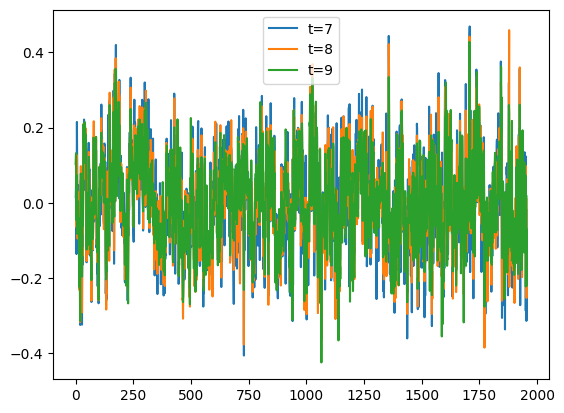

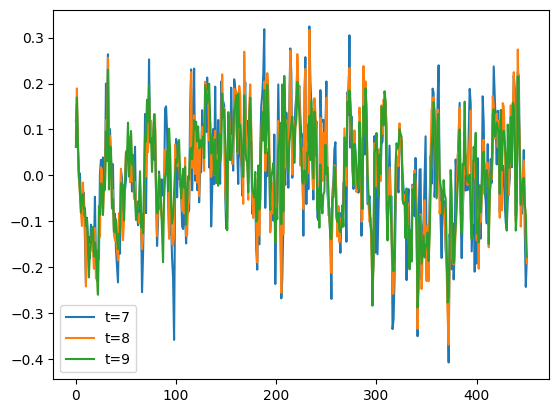

In [14]:
import matplotlib.pyplot as plt
target_task_idx=3

target_coeff = "0.1"
target_gradient_vals = gradient_vals_by_coeff[target_coeff]
gradient_vals = np.array(target_gradient_vals[target_task_idx])

for i in range(7, 10):
    # plot the mean of gradient over timesteps
    plt.plot(range(len(gradient_vals)), np.mean(gradient_vals[:,i,:], axis=-1), label=f"t={i}")
    plt.legend()

plt.show()

target_coeff = "0.5"
target_gradient_vals = gradient_vals_by_coeff[target_coeff]
gradient_vals = np.array(target_gradient_vals[target_task_idx])

for i in range(7, 10):
    # plot the mean of gradient over timesteps
    plt.plot(range(len(gradient_vals)), np.mean(gradient_vals[:,i,:], axis=-1), label=f"t={i}")
    plt.legend()


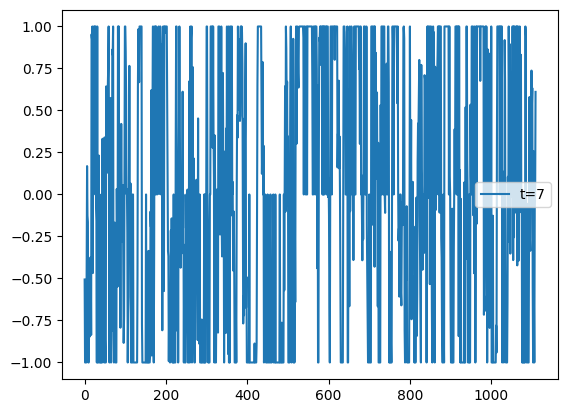

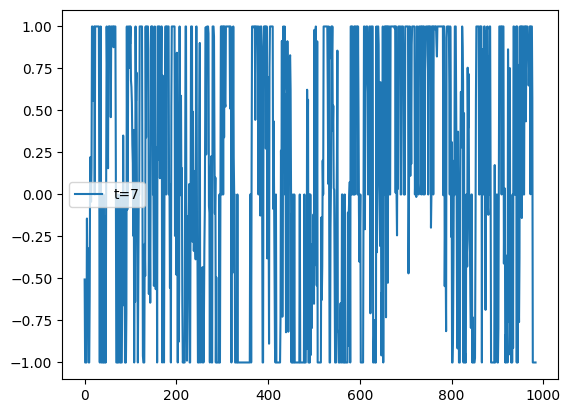

In [22]:
import matplotlib.pyplot as plt
target_task_idx=0
target_action_dim = 5

target_coeff = "0.01"
target_gradient_vals = gradient_vals_by_coeff[target_coeff]
gradient_vals = np.array(target_gradient_vals[target_task_idx])

start_step=7
end_step=8

for i in range(start_step, end_step):
    # plot the mean of gradient over timesteps
    plt.plot(range(len(gradient_vals)), gradient_vals[:,i,target_action_dim], label=f"t={i}")
    plt.legend()

plt.show()

target_coeff = "0.5"
target_gradient_vals = gradient_vals_by_coeff[target_coeff]
gradient_vals = np.array(target_gradient_vals[target_task_idx])

for i in range(start_step, end_step):
    # plot the mean of gradient over timesteps
    plt.plot(range(len(gradient_vals)), gradient_vals[:,i,target_action_dim], label=f"t={i}")
    plt.legend()


In [7]:
import matplotlib.pyplot as plt

target_coeff = "0.1"
target_task_idx=20

target_energy_vals = energy_vals_by_coeff[target_coeff]
target_gradient_vals = gradient_vals_by_coeff[target_coeff]

energy_vals = np.array(target_energy_vals[target_task_idx]).reshape(len(target_energy_vals[target_task_idx]), -1)
gradient_vals = np.array(target_gradient_vals[target_task_idx])

print(gradient_vals[200,7,:])

for i in range(7, 10):
    # plot the mean of gradient over timesteps
    plt.plot(range(len(gradient_vals)), np.mean(gradient_vals[:,i,:], axis=-1), label=f"t={i}")
    plt.legend()

plt.show()

target_coeff = "1.0"

target_energy_vals = energy_vals_by_coeff[target_coeff]
target_gradient_vals = gradient_vals_by_coeff[target_coeff]

energy_vals = np.array(target_energy_vals[target_task_idx]).reshape(len(target_energy_vals[target_task_idx]), -1)
gradient_vals = np.array(target_gradient_vals[target_task_idx])

for i in range(7, 10):
    # plot the mean of gradient over timesteps
    plt.plot(range(len(gradient_vals)), np.mean(gradient_vals[:,i,:], axis=-1), label=f"t={i}")
    plt.legend()


print(gradient_vals[500,7,:])

IndexError: list index out of range

In [18]:
target_timestep=4

temp = gradient_vals[target_timestep][-3,:]
temp_energy = energy_vals[target_timestep][-3]


print(f"Target Timestep: {target_timestep}")
print(f"Target Energy: {temp_energy}")
print(f"Target Gradient: {temp}")
print(f"Original Norm: {np.linalg.norm(temp)}")

print("Statistics:\n")
print(f"{output_stats(temp)}")

Target Timestep: 4
Target Energy: -6.662174224853516
Target Gradient: [-7.47993239e-04  2.92040035e-03 -3.09130806e-03 -1.12895633e-03
 -2.37996434e-03 -1.06749926e-02  6.89758162e-04  7.19760952e-04
  6.98754622e-04  1.57989771e-03  2.43380477e-04 -6.01172820e-03
 -8.01177230e-03  2.72798981e-03  5.42049311e-05 -2.08236859e-03
 -2.36926461e-03 -3.98734788e-04 -3.84969986e-03 -1.26286387e-03
 -9.69660468e-04]
Original Norm: 0.016697730513409312
Statistics:

(0.0029204003512859344, -0.010674992576241493, -0.0015878647713439672, 0.0032795658766487795)


In [61]:
from tqdm import tqdm

def cnt_oods(energy_vals, threshold=5, k=5):
    """
    Count the number of OOD actions based on the learned energy function (lower is better)
    
    Inputs:
        energy_vals: Numpy array of energy/safety values
        threshold: Threshold value to determine OOD actions (heuristics for now)
        k: Start counting from k-th flow steps
    """
    cnt = 0
    total = 0

    # Assume the array size of (num_timesteps, flow_steps)
    num_timesteps, flow_steps = energy_vals.shape
    for i in tqdm(range(num_timesteps)):
        for j in range(k-1, flow_steps):
            total += 1
            if energy_vals[i, j] > threshold:
                cnt += 1

    return cnt, total

cnt_oods(energy_vals, threshold=0, k=5)

100%|██████████| 783/783 [00:00<00:00, 334706.49it/s]


(1460, 4698)

In [ ]:
target_coeff = "0.01"

num_tasks = len(energy_vals_by_coeff[target_coeff])
failure_idx = []

oods = []
for i in tqdm(range(num_tasks)):
    target_energy_vals = energy_vals_by_coeff[target_coeff]
    target_gradient_vals = gradient_vals_by_coeff[target_coeff]
    target_lambda_vals = lambda_vals_by_coeff[target_coeff]

    if len(target_energy_vals[i]) == 1000:
        failure_idx.append(i)

    energy_vals = np.array(target_energy_vals[i]).reshape(len(target_energy_vals[i]), -1)
    gradient_vals = np.array(target_gradient_vals[i])
    lambda_vals = np.array(target_lambda_vals[i]).reshape(len(target_lambda_vals[i]))
    oods.append(cnt_oods(energy_vals, threshold=0, k=1))

100%|██████████| 50/50 [00:00<00:00, 121.54it/s]


In [102]:
failure_oods = np.array(oods)[failure_idx]
success_oods = np.array(oods)[[i for i in range(num_tasks) if i not in failure_idx]]

failure_acc = 0.
for i in range(len(failure_oods)):
    failure_acc += failure_oods[i][0] / (failure_oods[i][0] + failure_oods[i][1])

success_acc = 0.
for i in range(len(success_oods)):
    success_acc += success_oods[i][0] / (success_oods[i][0] + success_oods[i][1])

failure_acc / len(failure_oods), success_acc / len(success_oods)

(0.3470426664067587, 0.3573440514864468)

In [22]:
cos_vals = np.array(cosine_sim_vals_by_coeff["0.1"][3])[:,-3:]
grad_vals = np.array(gradient_vals_by_coeff["0.1"][3])[:,-3:]

In [37]:
idx=7
cos_vals[idx], grad_vals[idx].mean(axis=1)

(array([0.18891051, 0.22987358, 0.20908754]),
 array([-0.00707664, -0.00807304, -0.00758891]))

In [39]:
# quartile information
np.percentile(cos_vals, [0, 25, 50, 75, 100])

array([-0.65114999, -0.17179314, -0.01376475,  0.14153196,  0.67015463])

## Qualitative Analysis

In [1]:
import dotenv
%load_ext dotenv
%dotenv

import os
import platform
import json
import random
import time

import jax
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from absl import app, flags
from ml_collections import config_flags

from agents import agents
from envs.env_utils import make_env_and_datasets
from utils.datasets import Dataset, ReplayBuffer
from utils.evaluation import evaluate, flatten, supply_rng
from utils.flax_utils import restore_agent

import jax
import numpy as np
import matplotlib.pyplot as plt

def supply_rng(f, rng=jax.random.PRNGKey(0)):
    """Helper function to split the random number generator key before each call to the function."""

    def wrapped(*args, **kwargs):
        nonlocal rng
        rng, key = jax.random.split(rng)
        return f(*args, seed=key, **kwargs)

    return wrapped

# Configuration
env_name = "antmaze-large-navigate-singletask-task2-v0"
seed = 0
buffer_size = 2000000
eval_episodes = 10

# Agent paths and epochs
fbrac_antmaze_task1="/mnt/nas/jaehyeok/fql/exp/fql/Debug/fbrac_antmaze-large-navigate-singletask-task1-v0_sd002_20250908_200922_utd-ratio1"
fbrac_antmaze_task2="/mnt/nas/jaehyeok/fql/exp/fql/Debug/fbrac_antmaze-large-navigate-singletask-task2-v0_sd000_20250919_172341_utd-ratio1"
fbrac_antmaze_task3="/mnt/nas/jaehyeok/fql/exp/fql/Debug/fbrac_antmaze-large-navigate-singletask-task3-v0_sd000_20250919_172433_utd-ratio1"

# agent_path=a5_jacb_reg_e5_agent_path
agent_path=fbrac_antmaze_task2
restore_epoch=1000000

# Make environment and datasets
env, eval_env, train_dataset, val_dataset = make_env_and_datasets(env_name, frame_stack=None)
train_dataset = Dataset.create(**train_dataset)
train_dataset = ReplayBuffer.create_from_initial_dataset(
    dict(train_dataset), size=max(buffer_size, train_dataset.size + 1)
)

# Initialize random seeds
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
example_batch = train_dataset.sample(1)

# Load FQL agent configuration and create agent
from agents.fbrac import get_config as get_fbrac_config
fbrac_config = get_fbrac_config()

fbrac_agent_class = agents[fbrac_config['agent_name']]
fbrac_agent = fbrac_agent_class.create(
    seed,
    example_batch['observations'],
    example_batch['actions'],
    fbrac_config,
)

# Restore trained models
if agent_path and restore_epoch:
    fbrac_agent = restore_agent(fbrac_agent, agent_path, restore_epoch)
    print(f"FBRAC agent restored from {agent_path} at epoch {restore_epoch}")

print("Models loaded successfully!")

key = jax.random.PRNGKey(seed)
key

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/home/jaehyeok/miniconda3/envs/fql/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:14: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
/home/jaehyeok/miniconda3/envs/fql/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:14: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead


Restored from /mnt/nas/jaehyeok/fql/exp/fql/Debug/fbrac_antmaze-large-navigate-singletask-task2-v0_sd000_20250919_172341_utd-ratio1/params_1000000.pkl
FBRAC agent restored from /mnt/nas/jaehyeok/fql/exp/fql/Debug/fbrac_antmaze-large-navigate-singletask-task2-v0_sd000_20250919_172341_utd-ratio1 at epoch 1000000
Models loaded successfully!


Array([0, 0], dtype=uint32)

In [2]:
from utils.networks import LatentLyapunovFunction

def load_lyapunov_network(model_path, model_step, lyapunov_fn, state_dim, action_dim):
    """Load the saved Lyapunov network parameters."""
    import pickle
    
    # Load parameters
    params_path = os.path.join(model_path, f'lyapunov_params_step_{model_step}.npz')
    tree_path = os.path.join(model_path, f'lyapunov_tree_step_{model_step}.pkl')
    
    if not os.path.exists(params_path):
        raise FileNotFoundError(f"Parameters file not found: {params_path}")
    if not os.path.exists(tree_path):
        raise FileNotFoundError(f"Tree structure file not found: {tree_path}")
    
    # Load tree definition
    with open(tree_path, 'rb') as f:
        tree_def = pickle.load(f)
    
    # Load flattened parameters
    params_data = np.load(params_path)
    flat_params = [params_data[f'arr_{i}'] for i in range(len(params_data.files))]
    
    # Reconstruct parameter tree
    params = jax.tree_util.tree_unflatten(tree_def, flat_params)
    
    print(f"Loaded Lyapunov network from {model_path} at step {model_step}")
    return params

def create_energy_function(lyapunov_fn, lyapunov_params):
    """
    Create an energy function from the Lyapunov function.
    The energy function should return lower values for safer actions.
    """
    def energy_fn(observations, actions):
        try:
            # Use the Lyapunov function to compute energy
            # The model gives higher V(s,a) for safe actions, so we negate to get lower energy for safe actions
            lyapunov_values = lyapunov_fn.apply(lyapunov_params, observations, actions)
            # Return negative Lyapunov values as energy (lower energy = safer)
            return -lyapunov_values
        except Exception as e:
            print(f"Error in energy function: {e}")
            # Return zero energy if there's an error
            return jnp.zeros(observations.shape[0])
    
    # JIT compile the energy function for better performance
    return jax.jit(energy_fn)

# Get state and action dimensions from environment
state_dim = example_batch['observations'].shape[-1]
action_dim = example_batch['actions'].shape[-1]

# Create Lyapunov network
hidden_dims = [512,512,512]
latent_dim=16
layer_norm=False
lyapunov_fn = LatentLyapunovFunction(
    hidden_dim=hidden_dims,
    state_dim=state_dim,
    action_dim=action_dim,
    latent_dim=latent_dim,
    layer_norm=layer_norm
)

lyp_antmaze_task1="/mnt/nas/jaehyeok/fql/exp/lyapunov/LyapunovTraining/lyapunov_antmaze-large-navigate-singletask-task1-v0_sd000_20250916_202904"
lyp_antmaze_task2="/mnt/nas/jaehyeok/fql/exp/lyapunov/LyapunovTraining/lyapunov_antmaze-large-navigate-singletask-task2-v0_sd000_20250919_172659"
lyp_antmaze_task3="/mnt/nas/jaehyeok/fql/exp/lyapunov/LyapunovTraining/lyapunov_antmaze-large-navigate-singletask-task3-v0_sd000_20250919_172726"

lyapunov_model_path=lyp_antmaze_task2


# Load trained parameters
lyapunov_params = load_lyapunov_network(
    lyapunov_model_path, 
    1000000, 
    lyapunov_fn, 
    state_dim, 
    action_dim
)

# Create energy function
energy_fn = create_energy_function(lyapunov_fn, lyapunov_params)

Loaded Lyapunov network from /mnt/nas/jaehyeok/fql/exp/lyapunov/LyapunovTraining/lyapunov_antmaze-large-navigate-singletask-task2-v0_sd000_20250919_172659 at step 1000000


In [3]:
from tqdm import tqdm, trange

def evaluate_with_guidance(
    agent,
    env,
    energy_fn,
    config=None,
    num_eval_episodes=50,
    eval_temperature=0,
    guidance_coeff=1.0,
    partial_guidance=-1,
    seed=0,
    key=None,
    use_cov=False,
):
    """Evaluate the agent in the environment using guided sampling.

    Args:
        agent: Agent with sample_action_with_guidance method.
        env: Environment.
        energy_fn: Energy function for guidance.
        config: Configuration dictionary.
        num_eval_episodes: Number of episodes to evaluate the agent.
        eval_temperature: Action sampling temperature.
        guidance_coeff: Guidance strength coefficient.
        partial_guidance: If -1, apply guidance for entire sampling process.
                         If > 0 and < flow_steps, apply guidance only to last {partial_guidance} steps.
        use_cov: Whether to use covariance-based guidance coefficient estimation.

    Returns:
        A tuple containing the statistics, trajectories, energy values, gradient values, and lambda values.
    """
    from collections import defaultdict
    
    # Create guided actor function
    def guided_actor_fn(observations, seed=None, temperature=eval_temperature):
        try:
            if use_cov:
                # Use covariance-based guidance method
                return agent.sample_action_with_guidance_cov(
                    observations=observations,
                    energy_fn=energy_fn,
                    seed=seed,
                    n_samples=16,
                    eta=1.0,
                    eps=1e-6,
                    lambda_min=0.0,
                    lambda_max=3.0,
                    temperature=temperature,
                    partial_guidance=partial_guidance
                )
            else:
                # Use regular fixed coefficient guidance method
                return agent.sample_action_with_guidance(
                    observations=observations,
                    energy_fn=energy_fn,
                    seed=seed,
                    guidance_coeff=guidance_coeff,
                    temperature=temperature,
                    partial_guidance=partial_guidance
                )
        except Exception as e:
            print(f"Error in guided actor function: {e}")
            # Fall back to regular sampling if guidance fails
            return agent.sample_actions(observations, seed=seed, temperature=temperature)
    
    # JIT-compile the guided actor function for better performance
    method_name = "covariance-based" if use_cov else "fixed coefficient"
    print(f"JIT-compiling {method_name} guided actor function for coeff={guidance_coeff}...")
    if key is None:
        key = jax.random.PRNGKey(int(seed))
    guided_actor_fn = jax.jit(guided_actor_fn)
    trajs = []
    stats = defaultdict(list)
    energy_vals_by_episode = []
    gradient_vals_by_episode = []
    lambda_vals_by_episode = []
    cosine_sim_vals_by_episode = []

    for i in trange(num_eval_episodes, desc=f"Evaluating coeff={guidance_coeff}"):
        key, ep_key = jax.random.split(key)
        traj = defaultdict(list)
        energy_vals_list = []
        gradient_vals_list = []
        lambda_vals_list = []
        cosine_sim_vals_list = []
        observation, info = env.reset(seed=i)
        done = False
        step = 0
        while not done:
            key, action_key = jax.random.split(key)
            result = guided_actor_fn(observations=observation, temperature=eval_temperature, seed=action_key)
            # Handle different return formats based on guidance method
            if isinstance(result, tuple) and len(result) == 5:
                # Covariance method returns (action, energy_vals, gradient_vals, lambda_vals, cosine_sim_vals)
                action, energy_vals, gradient_vals, lambda_vals, cosine_sim_vals = result
                energy_vals_list.append(energy_vals)
                gradient_vals_list.append(gradient_vals)
                lambda_vals_list.append(lambda_vals)
                cosine_sim_vals_list.append(cosine_sim_vals)
            elif isinstance(result, tuple) and len(result) == 4:
                # Regular method returns (action, energy_vals, gradient_vals, cosine_sim_vals)
                action, energy_vals, gradient_vals, cosine_sim_vals = result
                energy_vals_list.append(energy_vals)
                gradient_vals_list.append(gradient_vals)
                cosine_sim_vals_list.append(cosine_sim_vals)
                # Create dummy lambda values if not provided
                lambda_vals_list.append([0.0])
            elif isinstance(result, tuple) and len(result) == 3:
                # Legacy format: (action, energy_vals, gradient_vals)
                action, energy_vals, gradient_vals = result
                energy_vals_list.append(energy_vals)
                gradient_vals_list.append(gradient_vals)
                # Create dummy lambda and cosine similarity values if not provided
                lambda_vals_list.append([0.0])
                cosine_sim_vals_list.append([0.0])
            elif isinstance(result, tuple) and len(result) == 2:
                action, energy_vals = result
                energy_vals_list.append(energy_vals)
                # Create dummy gradient, lambda, and cosine similarity values if not provided
                gradient_vals_list.append([jnp.zeros_like(observation)])
                lambda_vals_list.append([0.0])
                cosine_sim_vals_list.append([0.0])
            else:
                action = result
                # Create dummy energy, gradient, lambda, and cosine similarity values if not provided
                energy_vals_list.append(jnp.zeros(1))
                gradient_vals_list.append([jnp.zeros_like(observation)])
                lambda_vals_list.append([0.0])
                cosine_sim_vals_list.append([0.0])
            
            action = np.array(action)
            action = np.clip(action, -1, 1)

            next_observation, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            step += 1

            transition = dict(
                observation=observation,
                next_observation=next_observation,
                action=action,
                reward=reward,
                done=done,
                info=info,
            )
            from utils.evaluation import add_to
            add_to(traj, transition)
            observation = next_observation
        energy_vals_by_episode.append(energy_vals_list)
        gradient_vals_by_episode.append(gradient_vals_list)
        lambda_vals_by_episode.append(lambda_vals_list)
        cosine_sim_vals_by_episode.append(cosine_sim_vals_list)
        add_to(stats, flatten(info))
        trajs.append(traj)

    # Keep energy values as list of lists (no padding needed)
    # Convert JAX arrays to regular Python lists for consistency
    if energy_vals_by_episode and len(energy_vals_by_episode) > 0:
        converted_episodes = []
        for episode_vals in energy_vals_by_episode:
            # Convert JAX arrays to Python lists
            episode_list = []
            for val in episode_vals:
                if hasattr(val, 'tolist'):
                    # If it's a JAX array, convert to list
                    episode_list.append(val.tolist())
                elif isinstance(val, (list, tuple)):
                    # If it's already a list/tuple, keep as is
                    episode_list.append(list(val))
                else:
                    # If it's a single value, convert to float
                    episode_list.append(float(val))
            converted_episodes.append(episode_list)
        energy_vals_by_episode = converted_episodes
    else:
        # No energy values collected, keep as empty list
        energy_vals_by_episode = []

    # Convert gradient values to regular Python lists for consistency
    if gradient_vals_by_episode and len(gradient_vals_by_episode) > 0:
        converted_gradient_episodes = []
        for episode_vals in gradient_vals_by_episode:
            # Convert JAX arrays to Python lists
            episode_list = []
            for val in episode_vals:
                if hasattr(val, 'tolist'):
                    # If it's a JAX array, convert to list
                    episode_list.append(val.tolist())
                elif isinstance(val, (list, tuple)):
                    # If it's already a list/tuple, keep as is
                    episode_list.append(list(val))
                else:
                    # If it's a single value, convert to float
                    episode_list.append(float(val))
            converted_gradient_episodes.append(episode_list)
        gradient_vals_by_episode = converted_gradient_episodes
    else:
        # No gradient values collected, keep as empty list
        gradient_vals_by_episode = []

    # Convert lambda values to regular Python lists for consistency
    if lambda_vals_by_episode and len(lambda_vals_by_episode) > 0:
        converted_lambda_episodes = []
        for episode_vals in lambda_vals_by_episode:
            # Convert JAX arrays to Python lists
            episode_list = []
            for val in episode_vals:
                if hasattr(val, 'tolist'):
                    # If it's a JAX array, convert to list
                    episode_list.append(val.tolist())
                elif isinstance(val, (list, tuple)):
                    # If it's already a list/tuple, keep as is
                    episode_list.append(list(val))
                else:
                    # If it's a single value, convert to float
                    episode_list.append(float(val))
            converted_lambda_episodes.append(episode_list)
        lambda_vals_by_episode = converted_lambda_episodes
    else:
        # No lambda values collected, keep as empty list
        lambda_vals_by_episode = []

    # Convert cosine similarity values to regular Python lists for consistency
    if cosine_sim_vals_by_episode and len(cosine_sim_vals_by_episode) > 0:
        converted_cosine_sim_episodes = []
        for episode_vals in cosine_sim_vals_by_episode:
            # Convert JAX arrays to Python lists
            episode_list = []
            for val in episode_vals:
                if hasattr(val, 'tolist'):
                    # If it's a JAX array, convert to list
                    episode_list.append(val.tolist())
                elif isinstance(val, (list, tuple)):
                    # If it's already a list/tuple, keep as is
                    episode_list.append(list(val))
                else:
                    # If it's a single value, convert to float
                    episode_list.append(float(val))
            converted_cosine_sim_episodes.append(episode_list)
        cosine_sim_vals_by_episode = converted_cosine_sim_episodes
    else:
        # No cosine similarity values collected, keep as empty list
        cosine_sim_vals_by_episode = []

    for k, v in stats.items():
        stats[k] = np.mean(v)

    return stats, trajs, energy_vals_by_episode, gradient_vals_by_episode, lambda_vals_by_episode, cosine_sim_vals_by_episode

In [8]:
# Un-guided evaluation
eval_info, trajs, energy_vals, gradient_vals, lambda_vals, cos_sim_vals = evaluate_with_guidance(
    agent=fbrac_agent,
    config=fbrac_config,
    env=eval_env,
    energy_fn=energy_fn,
    num_eval_episodes=50,
    guidance_coeff=1.0,
    partial_guidance=1,
    seed=seed,
    key=key,
)

eval_info

JIT-compiling fixed coefficient guided actor function for coeff=1.0...


Evaluating coeff=1.0: 100%|██████████| 50/50 [00:49<00:00,  1.01it/s]


defaultdict(list,
            {'xy': 12.299311960790181,
             'prev_qpos': 1.6946167546665878,
             'prev_qvel': -0.03951330841198492,
             'qpos': 1.688893383093673,
             'qvel': -0.07728258404114405,
             'success': 0.84,
             'total.timesteps': 77857.14,
             'episode.final_reward': -0.16,
             'episode.return': -692.82,
             'episode.length': 693.66,
             'episode.duration': 0.9847418355941773})

In [ ]:
cos_sim_vals[0]

654